In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

print('Environment ready.')

Environment ready.


In [5]:
INDEX_COLS   = ['unit_number', 'time_cycles']
OP_SETTINGS  = ['setting_1', 'setting_2', 'setting_3']
SENSOR_NAMES = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
COL_NAMES = INDEX_COLS + OP_SETTINGS + SENSOR_NAMES

BASE = '/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps'
READ_KW = dict(sep=r'\s+', header=None, names=COL_NAMES, engine='python')

train = pd.read_csv(f'{BASE}/train_FD001.txt', **READ_KW)
test  = pd.read_csv(f'{BASE}/test_FD001.txt',  **READ_KW)
rul   = pd.read_csv(f'{BASE}/RUL_FD001.txt',   sep=r'\s+', header=None, names=['RUL'], engine='python')

print(f'Train: {train.shape} | Test: {test.shape} | RUL: {rul.shape}')
print(f'Nulls — Train: {train.isnull().sum().sum()} | Test: {test.isnull().sum().sum()}')

Train: (20631, 26) | Test: (13096, 26) | RUL: (100, 1)
Nulls — Train: 0 | Test: 0


**2 Data Control**

In [6]:
# --- 2a. Remove constant (dead) sensors ---

dead = [c for c in train.columns if train[c].nunique() <= 1]
train.drop(columns=dead, inplace=True)
test.drop(columns=dead, inplace=True)
print(f'Dropped {len(dead)} dead sensors: {dead}')

# --- 2b. Compute + clip RUL ---
RUL_CAP = 125

max_cycle = train.groupby('unit_number')['time_cycles'].max().rename('max_cycle')
train = train.join(max_cycle, on='unit_number')
train['RUL'] = (train['max_cycle'] - train['time_cycles']).clip(upper=RUL_CAP)
train.drop(columns='max_cycle', inplace=True)

print(f'RUL capped at {RUL_CAP}. Distribution:\n{train["RUL"].describe().round(1).to_string()}')

Dropped 7 dead sensors: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
RUL capped at 125. Distribution:
count    20631.0
mean        86.8
std         41.7
min          0.0
25%         51.0
50%        103.0
75%        125.0
max        125.0


 **3 Exploratory Data Analysis**

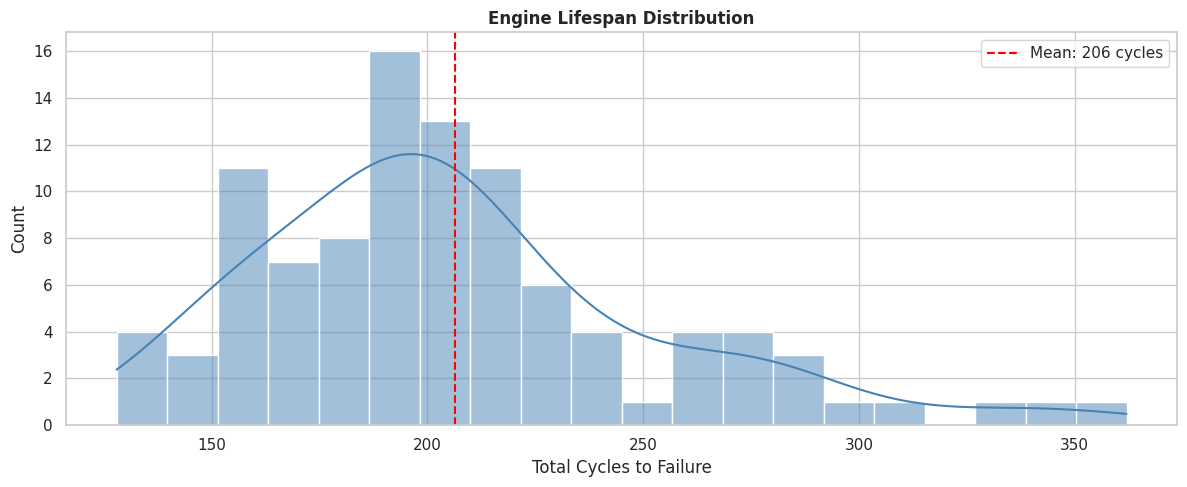

In [7]:
# --- 3a. Engine lifespan distribution ---
lifespan = train.groupby('unit_number')['time_cycles'].max()

plt.figure()
sns.histplot(lifespan, kde=True, bins=20, color='steelblue')
plt.axvline(lifespan.mean(), color='red', linestyle='--', label=f'Mean: {lifespan.mean():.0f} cycles')
plt.title('Engine Lifespan Distribution', fontweight='bold')
plt.xlabel('Total Cycles to Failure')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

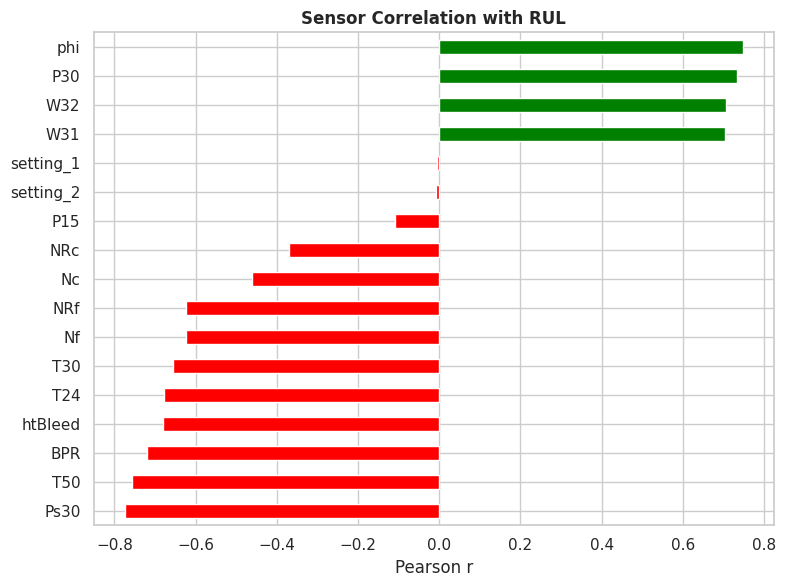

Top 5 informative sensors: ['Ps30', 'T50', 'phi', 'P30', 'BPR']


In [8]:
# --- 3b. Sensor correlation with RUL ---
feature_cols = [c for c in train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]
rul_corr = train[feature_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(8, 6))
rul_corr.plot(kind='barh', color=['red' if v < 0 else 'green' for v in rul_corr])
plt.title('Sensor Correlation with RUL', fontweight='bold')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

# Top 5 most correlated sensors
top_sensors = rul_corr.abs().nlargest(5).index.tolist()
print('Top 5 informative sensors:', top_sensors)